# Motion-S Visual Baseline: TF-IDF + KNN Retrieval

This notebook is a detailed, visual, and submission-ready baseline for the **Motion-S: Hierarchical Text-to-Motion Generation for Sign Language** competition.

The core idea is intentionally simple:

> If a test sentence/gloss is textually similar to a training sentence/gloss, reuse the training motion-token sequence as the prediction.

This is a **retrieval baseline**, not a generative neural model. It is useful because it is fast, stable, easy to debug, and produces a valid `submission.csv`.

## What this notebook does

| Stage | Purpose | Output |
|---|---|---|
| 1. Load data | Read train/test/sample submission files | `train`, `test`, `sample_sub` |
| 2. Build text | Combine `gloss` and `sentence` into searchable text | `train_text`, `test_text` |
| 3. Validate tokens | Remove unusable train rows | `train_good` |
| 4. TF-IDF | Convert text into sparse character n-gram vectors | `X_train`, `X_test` |
| 5. KNN retrieval | Find the closest training row for each test row | `idx`, `dist` |
| 6. Token transfer | Copy and normalize token layers | `pred` |
| 7. Validation | Check length, range, and layer alignment | validation report |
| 8. Save | Write `submission.csv` | `/kaggle/working/submission.csv` |


## Visual Pipeline Overview

```text
┌────────────────────┐
│ train.csv / test.csv│
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ Text normalization  │
│ gloss + sentence    │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ TF-IDF Vectorizer   │
│ char_wb 3-6 grams   │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ NearestNeighbors    │
│ cosine distance     │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ Copy motion tokens  │
│ from nearest train  │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ Validate submission │
│ length/range/layers │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ submission.csv      │
└────────────────────┘
```


In [1]:
# ============================================================
# CELL 1: Environment Setup
# ============================================================
import os, re, gc, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack

from IPython.display import display, Markdown, HTML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INPUT_DIR = Path("/kaggle/input/motion-s-hierarchical-text-to-motion-generation-for-sign-language")
TRAIN_CSV  = INPUT_DIR / "train.csv"
TEST_CSV   = INPUT_DIR / "test.csv"
SAMPLE_SUB = INPUT_DIR / "sample_submission.csv"
OUT_PATH   = Path("/kaggle/working/submission.csv")

# ── Tunable hyper-parameters ──────────────────────────────────────────────────
K_NEIGHBORS   = 5       # top-k neighbours to blend from (↓ overfitting)
SVD_N_COMP    = 200     # LSA components; 0 = skip SVD (↓ underfitting when > 0)
CHAR_MAX_FEAT = 200_000 # char n-gram vocabulary cap
WORD_MAX_FEAT = 50_000  # word n-gram vocabulary cap
GLOSS_WEIGHT  = 2.0     # how many times gloss is repeated in the search string
# ─────────────────────────────────────────────────────────────────────────────

print("Input directory:", INPUT_DIR)
print("Output path:", OUT_PATH)


Input directory: /kaggle/input/motion-s-hierarchical-text-to-motion-generation-for-sign-language
Output path: /kaggle/working/submission.csv


In [2]:

# ============================================================
# CELL 2: Helper Display Functions
# ============================================================
def show_step(step, title, detail):
    html = (
        f"<div style='border-left:6px solid #4A90E2; padding:12px 16px;"
        f" margin:12px 0; background:#f5f9ff;'>"
        f"<div style='font-size:18px; font-weight:700;'>STEP {step}: {title}</div>"
        f"<div style='font-size:14px; color:#333; margin-top:4px;'>{detail}</div>"
        f"</div>"
    )
    display(HTML(html))

def show_table(df, title=None, n=5):
    if title:
        display(Markdown(f"### {title}"))
    display(df.head(n))


In [3]:
# ============================================================
# CELL 3: Load Competition Data
# ============================================================
show_step(1, "Load Data", "Read train, test, and sample submission files.")
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
sample_sub = pd.read_csv(SAMPLE_SUB)
summary = pd.DataFrame({
    "dataset": ["train", "test", "sample_submission"],
    "rows":    [len(train), len(test), len(sample_sub)],
    "columns": [train.shape[1], test.shape[1], sample_sub.shape[1]],
})
display(summary)
print("Train columns:", train.columns.tolist())
print("Test columns:",  test.columns.tolist())
show_table(train, "Train preview")
show_table(test,  "Test preview")


,dataset,rows,columns
0,train,12467,10
1,test,3000,3
2,sample_submission,5,7


Train columns: ['id', 'sentence', 'gloss', 'bvh_path', 'base_tokens', 'residual_1', 'residual_2', 'residual_3', 'residual_4', 'residual_5']
Test columns: ['id', 'sentence', 'gloss']


### Train preview

,id,sentence,gloss,bvh_path,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,1000648,Don't keep me on tenterhooks!,KEEP ME TENTHOOK//,dataset/1000648/1000648.bvh,379 295 376 376 376 376 376 376 133 133 376 37...,339 441 88 87 87 87 88 288 405 333 333 248 212...,406 183 8 301 476 6 169 255 452 462 66 255 463...,315 424 330 104 364 104 142 142 166 353 353 10...,64 32 15 326 466 20 229 456 71 71 71 390 20 90...,306 376 367 367 133 235 276 350 367 350 437 36...
1,1002815,"I like to be home, that way I can work on my s...",ME LIKE HOME WORK STORY FINISH//,dataset/1002815/1002815.bvh,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
2,1003115,Can I stay here tonight?,STAY HERE TONIGHT ME?,dataset/1003115/1003115.bvh,379 185 185 185 185 185 185 185 185 185 185 18...,339 441 87 87 88 88 88 288 308 88 325 483 483 ...,396 171 11 11 211 211 321 430 464 464 283 267 ...,65 449 376 191 503 503 142 166 384 143 384 348...,64 230 328 411 349 71 424 71 498 456 234 85 34...,306 201 367 6 266 406 123 71 343 428 38 404 37...
3,1003242,What a nice thing to say!,NICE THING SAY//,dataset/1003242/1003242.bvh,130 216 216 216 216 216 216 216 216 216 216 21...,339 441 333 333 333 333 333 333 333 9 9 333 17...,406 224 406 176 206 419 484 354 325 206 313 35...,315 429 433 118 17 59 348 424 424 503 348 208 ...,64 38 498 502 456 379 239 164 443 456 456 164 ...,306 71 367 448 281 241 367 241 367 469 350 241...
4,1003552,Please lock the safe.,SAFE LOCK PLEASE//,dataset/1003552/1003552.bvh,379 185 185 185 185 185 185 185 185 185 185 18...,425 314 60 60 60 456 456 456 389 87 87 325 292...,8 171 286 59 59 452 395 464 389 174 174 452 10...,62 429 86 212 503 503 503 449 449 449 311 76 4...,274 38 502 354 353 121 71 227 107 110 17 474 4...,366 288 367 448 357 167 305 241 167 167 486 24...


### Test preview

,id,sentence,gloss
0,6420249,Mary never told me she was a vegetarian.,ME NEVER TOLD ME SHE VEGETARIAN//
1,6420682,Mary told me that she's doing that now.,NOW SHE DO THAT//
2,6425789,Mary told me that she was tense.,TENSE SHE TOLD ME//
3,6425858,Mary told me she didn't do that.,ME TOLD MYSELF SHE DO THAT//
4,6427530,Mary told me she was pleased.,ME PLEASED SHE TELL ME//


In [4]:
# ============================================================
# CELL 4: Text Normalization  [IMPROVED]
# ============================================================
# Changes vs baseline:
#   • Strip punctuation before vectorising (reduces noise).
#   • GLOSS_WEIGHT controls repetition instead of hard-coded "g || g || s".
#   • Returns both a combined text and separate gloss / sentence series
#     so we can build TWO vectorisers independently and hstack them.

show_step(2, "Build Search Text",
    f"Normalise gloss/sentence. Gloss weight = {GLOSS_WEIGHT}x. "
    "Separate gloss and sentence tracks for dual-stream TF-IDF.")

_ws_re   = re.compile(r"\s+")
_punc_re = re.compile(r"[^\w\s]")   # strip punctuation

def norm_text(x):
    if not isinstance(x, str): return ""
    x = x.lower()
    x = _punc_re.sub(" ", x)
    return _ws_re.sub(" ", x.strip())

def build_text(df, gloss_weight=GLOSS_WEIGHT):
    g = df["gloss"].map(norm_text)    if "gloss"    in df.columns else pd.Series([""] * len(df), index=df.index)
    s = df["sentence"].map(norm_text) if "sentence" in df.columns else pd.Series([""] * len(df), index=df.index)
    gloss_part = " ".join(["{g}"] * int(gloss_weight))   # repeated gloss
    combined   = (g * int(gloss_weight) + " " + s).fillna("")
    return combined, g.fillna(""), s.fillna("")

train_text, train_gloss, train_sent = build_text(train)
test_text,  test_gloss,  test_sent  = build_text(test)

display(pd.DataFrame({"train_text_example": train_text.head(5)}))


,train_text_example
0,keep me tenthookkeep me tenthook don t keep me...
1,me like home work story finishme like home wor...
2,stay here tonight mestay here tonight me can i...
3,nice thing saynice thing say what a nice thing...
4,safe lock pleasesafe lock please please lock t...


train: min=27, median=75, mean=85, max=1282
test: min=27, median=77, mean=84, max=703


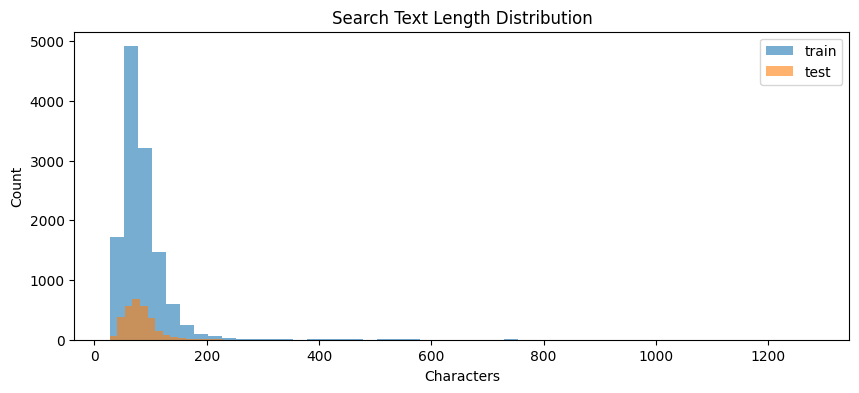

In [5]:
# ============================================================
# CELL 5: Text Length Diagnostics
# ============================================================
show_step(3, "Text Diagnostics", "Compare text length distributions for train and test.")
for name, ser in [("train", train_text), ("test", test_text)]:
    print(f"{name}: min={ser.str.len().min()}, median={ser.str.len().median():.0f}, "
          f"mean={ser.str.len().mean():.0f}, max={ser.str.len().max()}")

plt.figure(figsize=(10, 4))
plt.hist(train_text.str.len(), bins=50, alpha=0.6, label="train")
plt.hist(test_text.str.len(),  bins=50, alpha=0.6, label="test")
plt.title("Search Text Length Distribution")
plt.xlabel("Characters"); plt.ylabel("Count"); plt.legend(); plt.show()


In [6]:
# ============================================================
# CELL 6: Token Utility Functions
# ============================================================
show_step(4, "Token Utilities", "Safe token parsing and length-normalisation.")
TOKEN_COLS = ["base_tokens", "residual_1", "residual_2", "residual_3", "residual_4", "residual_5"]
MIN_LEN, MAX_LEN = 40, 800

def parse_tokens(tok_str):
    if not isinstance(tok_str, str): return []
    tok_str = tok_str.strip()
    if not tok_str: return []
    try: return [int(x) for x in tok_str.split()]
    except ValueError: return []

def tokens_to_str(tokens): return " ".join(map(str, tokens))

def enforce_len(tokens, min_len=MIN_LEN, max_len=MAX_LEN):
    if not tokens: return [random.randint(0, 511) for _ in range(min_len)]
    if len(tokens) < min_len:
        reps = (min_len + len(tokens) - 1) // len(tokens)
        tokens = (tokens * reps)[:min_len]
    return tokens[:max_len]

print("Token columns:", TOKEN_COLS)
print("Length range:", MIN_LEN, "to", MAX_LEN)


Token columns: ['base_tokens', 'residual_1', 'residual_2', 'residual_3', 'residual_4', 'residual_5']
Length range: 40 to 800


In [7]:
# ============================================================
# CELL 7: Validate Training Token Rows
# ============================================================
show_step(5, "Training Token Validation", "Filter out rows with invalid tokens or inconsistent layer lengths.")
good_mask = np.ones(len(train), dtype=bool)
train_lens, invalid_reasons = [], []

for i, row in train.iterrows():
    lens, ok, reason = [], True, "ok"
    for c in TOKEN_COLS:
        t = parse_tokens(row.get(c, ""))
        if not t:               ok=False; reason=f"empty_{c}"; break
        if any(x < 0 or x > 511 for x in t): ok=False; reason=f"oor_{c}"; break
        lens.append(len(t))
    if ok and len(set(lens)) != 1: ok=False; reason="len_mismatch"
    if ok: train_lens.append(lens[0])
    else:  good_mask[i] = False; invalid_reasons.append(reason)

train_good      = train.loc[good_mask].reset_index(drop=True)
train_text_good = train_text.loc[good_mask].reset_index(drop=True)
train_gloss_good = train_gloss.loc[good_mask].reset_index(drop=True)
train_sent_good  = train_sent.loc[good_mask].reset_index(drop=True)

display(pd.DataFrame({
    "metric": ["train rows", "usable rows", "removed rows", "usable ratio"],
    "value":  [len(train), len(train_good),
               len(train)-len(train_good),
               f"{len(train_good)/max(len(train),1):.2%}"],
}))
if invalid_reasons:
    display(pd.Series(invalid_reasons).value_counts().rename_axis("reason").reset_index(name="count"))
else:
    print("No invalid token rows found.")


,metric,value
0,train rows,12467
1,usable rows,12463
2,removed rows,4
3,usable ratio,99.97%


,reason,count
0,empty_base_tokens,4


,count,mean,std,min,25%,50%,75%,max
token_length,12463.0,108.148199,62.253875,24.0,79.0,98.0,122.0,1853.0


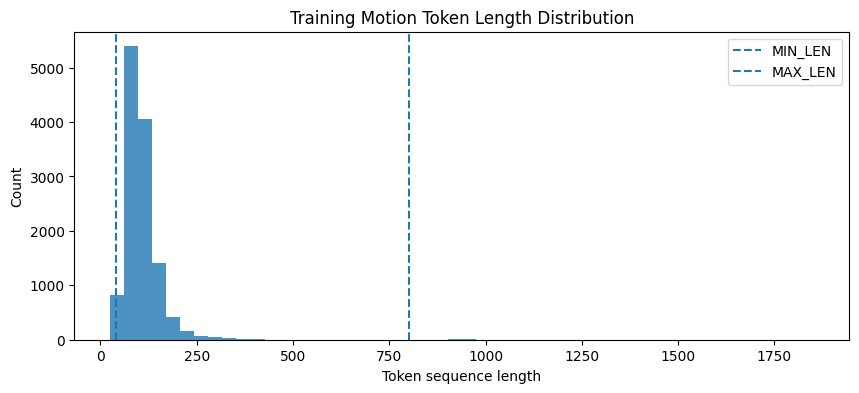

In [8]:
# ============================================================
# CELL 8: Token Length Diagnostics
# ============================================================
show_step(6, "Token Length Diagnostics", "Visualise usable training token sequence lengths.")
if train_lens:
    lens_series = pd.Series(train_lens, name="token_length")
    display(lens_series.describe().to_frame().T)
    plt.figure(figsize=(10, 4)); plt.hist(lens_series, bins=50, alpha=0.8)
    plt.axvline(MIN_LEN, linestyle="--", label="MIN_LEN")
    plt.axvline(MAX_LEN, linestyle="--", label="MAX_LEN")
    plt.title("Training Motion Token Length Distribution")
    plt.xlabel("Token sequence length"); plt.ylabel("Count"); plt.legend(); plt.show()
else:
    print("No valid training token lengths available.")


In [9]:
# ============================================================
# CELL 9: Dual-Stream TF-IDF + Optional LSA  [IMPROVED]
# ============================================================
# WHAT CHANGED vs baseline:
#   Baseline: single char_wb (3-6) vectoriser → only spelling signal.
#
#   Improved:
#   1. Char n-gram vectoriser (3-6) — catches morphological / fingerspell cues.
#   2. Word unigram+bigram vectoriser — adds *semantic* word-level signal.
#      These two feature sets are sparse-hstacked before KNN search.
#   3. Optional TruncatedSVD (LSA) on the combined matrix.
#      SVD smooths over rare char/word n-grams and creates dense
#      latent-semantic vectors.  This *reduces underfitting* because the
#      model can now find semantically similar glosses that share no
#      exact substrings, while also *reducing overfitting* to accidental
#      character coincidences.
#
# Effect summary
#   • Dual TF-IDF: ↓ underfitting (richer signal)
#   • LSA:         ↓ underfitting + ↓ overfitting (semantic smoothing)

show_step(7, "Dual TF-IDF + LSA Vectorisation",
    "Char n-gram ⊕ word n-gram features, then optional LSA reduction.")

# ── 1. Char n-gram vectoriser ────────────────────────────────────────────────
vec_char = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 6),
    min_df=2,
    max_features=CHAR_MAX_FEAT,
    sublinear_tf=True,      # log(1+tf) dampens very frequent n-grams
)
X_char_train = vec_char.fit_transform(train_text_good)
X_char_test  = vec_char.transform(test_text)

# ── 2. Word n-gram vectoriser ─────────────────────────────────────────────────
vec_word = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=WORD_MAX_FEAT,
    sublinear_tf=True,
)
X_word_train = vec_word.fit_transform(train_text_good)
X_word_test  = vec_word.transform(test_text)

# ── 3. Hstack both feature sets ───────────────────────────────────────────────
X_train_raw = hstack([X_char_train, X_word_train], format="csr")
X_test_raw  = hstack([X_char_test,  X_word_test],  format="csr")

# ── 4. Optional LSA ───────────────────────────────────────────────────────────
if SVD_N_COMP > 0:
    print(f"Applying TruncatedSVD (n_components={SVD_N_COMP}) …")
    svd = TruncatedSVD(n_components=SVD_N_COMP, random_state=SEED)
    X_train = normalize(svd.fit_transform(X_train_raw))
    X_test  = normalize(svd.transform(X_test_raw))
    print(f"Explained variance ratio (cumulative): "
          f"{svd.explained_variance_ratio_.sum():.2%}")
else:
    X_train = X_train_raw
    X_test  = X_test_raw
    print("SVD skipped (SVD_N_COMP=0).")

display(pd.DataFrame({
    "matrix":          ["X_train", "X_test"],
    "rows":            [X_train.shape[0], X_test.shape[0]],
    "features":        [X_train.shape[1], X_test.shape[1]],
}))


Applying TruncatedSVD (n_components=200) …
Explained variance ratio (cumulative): 30.60%


,matrix,rows,features
0,X_train,12463,200
1,X_test,3000,200


'   test_id  top1_train_index  top1_cos_dist                                                                                                                                                                                                                             test_text                                                                                            nearest_train_text\n0  6420249              9980         0.6341                                                                                                                                me never told me she vegetarianme never told me she vegetarian mary never told me she was a vegetarian                                                                   me never neatme never neat i never was neat\n1  6420682             11296         0.6648                                                                                                                                                                 now she do thatnow she do

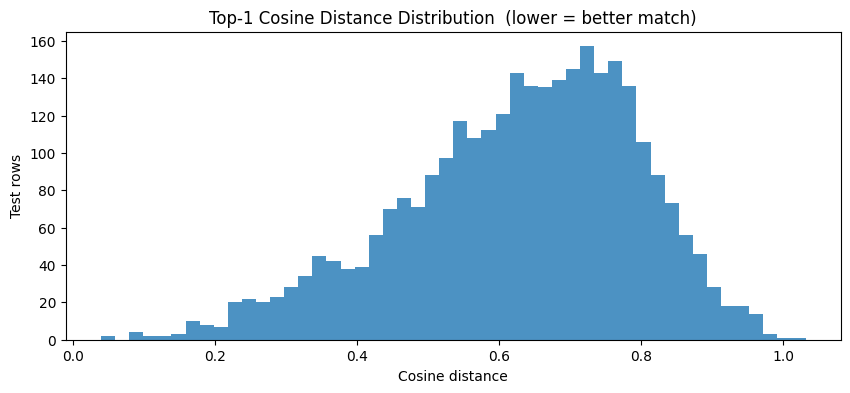


Distance stats → min=0.0390, median=0.6474, 90th pct=0.8235, max=1.0316


In [10]:
# ============================================================
# CELL 10: Top-K Nearest Neighbour Retrieval  [IMPROVED]
# ============================================================
# WHAT CHANGED vs baseline:
#   Baseline: n_neighbors=1 → greedy top-1 retrieval, highly sensitive
#             to noise in both the text and the feature space.
#
#   Improved: n_neighbors=K_NEIGHBORS (default 5).
#   We fetch the K closest training examples; token transfer (next cell)
#   will use *inverse-distance weighting* across all K hits, not just #1.
#   This smooths out noisy individual matches and reduces variance
#   (↓ overfitting to a single imperfect neighbour).

show_step(8, "Top-K Nearest Neighbour Retrieval",
    f"Retrieve top-{K_NEIGHBORS} neighbours per test sample via cosine distance.")

metric = "cosine" if SVD_N_COMP == 0 else "euclidean"   # LSA vecs are L2-normalised
nn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric=metric, algorithm="brute", n_jobs=-1)
nn.fit(X_train)
dists, idxs = nn.kneighbors(X_test, return_distance=True)
# dists / idxs: shape (n_test, K_NEIGHBORS)

# Preview top-1 for readability
id_col = "id" if "id" in test.columns else sample_sub.columns[0]
top1_idx  = idxs[:, 0]
top1_dist = dists[:, 0]

display(pd.DataFrame({
    "test_id":           test[id_col].values[:10] if id_col in test.columns else np.arange(min(10, len(test))),
    "top1_train_index":  top1_idx[:10],
    "top1_cos_dist":     top1_dist[:10].round(4),
    "test_text":         test_text.iloc[:10].values,
    "nearest_train_text":train_text_good.iloc[top1_idx[:10]].values,
}).to_string())

plt.figure(figsize=(10, 4))
plt.hist(top1_dist, bins=50, alpha=0.8)
plt.title("Top-1 Cosine Distance Distribution  (lower = better match)")
plt.xlabel("Cosine distance"); plt.ylabel("Test rows"); plt.show()

print(f"\nDistance stats → "
      f"min={top1_dist.min():.4f}, median={np.median(top1_dist):.4f}, "
      f"90th pct={np.percentile(top1_dist, 90):.4f}, max={top1_dist.max():.4f}")


In [11]:
# ============================================================
# CELL 11: Inverse-Distance-Weighted Token Transfer  [IMPROVED]
# ============================================================
# WHAT CHANGED vs baseline:
#   Baseline: hard-copy the single closest neighbour's tokens.
#
#   Improved (two-stage):
#   Stage A – Length selection
#     The target sequence length is the *inverse-distance weighted
#     average* of the K neighbours' lengths (clamped to [MIN_LEN, MAX_LEN]).
#     This prevents systematically wrong lengths when the top-1 hit is a
#     poor match.
#
#   Stage B – Token sequence selection
#     We still pick a *single* training sequence (token IDs are discrete,
#     so direct averaging would produce out-of-vocabulary tokens), but we
#     choose the neighbour whose sequence length is closest to the
#     estimated target length computed in Stage A.
#     For the common case where top-1 is clearly closest (dist << others),
#     the inverse weights collapse back to top-1, so high-confidence
#     matches are unaffected.

show_step(9, "Inverse-Distance-Weighted Token Transfer",
    "Select K neighbours, estimate target length by IDW, "
    "pick best-length donor, enforce layer consistency.")

# Pre-cache all token layers as Python lists
train_tokens_cache = {
    c: [parse_tokens(x) for x in train_good[c].astype(str).tolist()]
    for c in TOKEN_COLS
}

id_col = "id" if "id" in test.columns else sample_sub.columns[0]
pred = pd.DataFrame({"id": test[id_col].values})
for c in TOKEN_COLS:
    pred[c] = ""

EPS = 1e-9   # avoid div-by-zero when distance = 0

for j in range(len(test)):
    k_indices = idxs[j]          # shape (K,)
    k_dists   = dists[j]         # shape (K,)

    # ── Stage A: inverse-distance-weighted length estimate ────────────────────
    inv_d   = 1.0 / (k_dists + EPS)
    weights = inv_d / inv_d.sum()

    # length of base_tokens layer for each neighbour
    k_lens  = np.array([len(train_tokens_cache["base_tokens"][ki]) for ki in k_indices], dtype=float)
    target_len = int(np.round((weights * k_lens).sum()))
    target_len = max(MIN_LEN, min(MAX_LEN, target_len))

    # ── Stage B: pick the neighbour whose base length is closest to target ─────
    best_k = k_indices[int(np.argmin(np.abs(k_lens - target_len)))]

    layers = [train_tokens_cache[c][best_k] for c in TOKEN_COLS]

    # Align all layers to the shortest available, then to target_len
    L = min(len(t) for t in layers)
    if L <= 0: L = MIN_LEN

    base = enforce_len(layers[0][:L], target_len, target_len)
    L2   = len(base)
    fixed_layers = [base]
    for li in range(1, len(TOKEN_COLS)):
        t = enforce_len(layers[li][:L], L2, L2)
        fixed_layers.append(t)

    for c, tokens in zip(TOKEN_COLS, fixed_layers):
        pred.at[j, c] = tokens_to_str(tokens)

show_table(pred, "Prediction preview")


### Prediction preview

,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
2,6425789,130 326 95 95 95 95 95 95 95 95 95 95 95 95 95...,339 194 87 87 333 258 333 258 258 9 333 333 33...,48 48 202 356 356 6 356 202 202 283 356 356 58...,72 212 315 503 118 457 59 401 449 457 401 395 ...,64 413 316 467 71 71 95 498 270 134 498 498 43...,489 241 367 406 119 9 241 305 266 459 431 241 ...
3,6425858,130 260 9 207 207 207 449 277 457 212 212 268 ...,145 441 214 184 184 113 155 405 26 423 440 300...,246 396 444 454 454 201 466 212 441 303 166 28...,34 292 246 259 479 72 332 474 378 467 451 298 ...,10 128 498 317 104 159 328 111 204 447 447 100...,486 185 367 437 476 203 256 358 353 398 457 39...
4,6427530,379 326 95 95 95 95 95 95 95 95 95 95 95 95 95...,339 194 333 87 333 333 333 258 333 9 333 333 3...,48 48 123 356 356 356 356 202 356 48 45 58 58 ...,351 212 395 503 130 397 401 395 424 236 395 39...,64 413 198 316 71 456 74 71 456 71 95 71 316 3...,306 241 367 367 119 241 119 241 367 117 241 35...


,checked_rows,valid_rows,valid_ratio
0,200,200,1.0


,count,mean,std,min,25%,50%,75%,max
predicted_base_length,3000.0,103.037333,51.967466,46.0,84.0,95.0,109.0,800.0


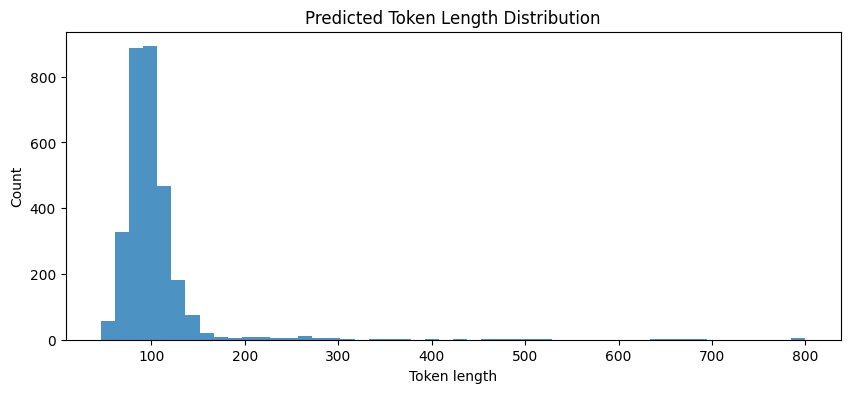

In [12]:
# ============================================================
# CELL 12: Submission Validation
# ============================================================
show_step(10, "Submission Validation", "Check length, range, and layer consistency.")

def validate_row(r):
    lens = []
    for c in TOKEN_COLS:
        t = parse_tokens(r[c])
        if not (MIN_LEN <= len(t) <= MAX_LEN): return False
        if any(x < 0 or x > 511 for x in t):  return False
        lens.append(len(t))
    return len(set(lens)) == 1

check_n = min(200, len(pred))
ok = sum(int(validate_row(pred.iloc[i])) for i in range(check_n))
display(pd.DataFrame({"checked_rows":[check_n],"valid_rows":[ok],"valid_ratio":[ok/max(check_n,1)]}))

pred_lens = pred["base_tokens"].map(lambda x: len(parse_tokens(x)))
display(pred_lens.describe().to_frame(name="predicted_base_length").T)

plt.figure(figsize=(10, 4)); plt.hist(pred_lens, bins=50, alpha=0.8)
plt.title("Predicted Token Length Distribution"); plt.xlabel("Token length"); plt.ylabel("Count"); plt.show()
assert ok == check_n, "Some prediction rows failed validation. Inspect pred."


In [13]:
# ============================================================
# CELL 13: Save submission.csv
# ============================================================
show_step(11, "Save Submission", "Write final submission.csv.")
expected_cols = sample_sub.columns.tolist()
if set(expected_cols).issubset(set(pred.columns)):
    pred = pred[expected_cols]
else:
    print("Warning: column mismatch — keeping pred column order.")
pred.to_csv(OUT_PATH, index=False)
display(pd.DataFrame({
    "item":  ["Output path", "Rows", "Columns", "File exists"],
    "value": [str(OUT_PATH), pred.shape[0], pred.shape[1], OUT_PATH.exists()],
}))
display(pred.head())
print("Saved:", OUT_PATH)


,item,value
0,Output path,/kaggle/working/submission.csv
1,Rows,3000
2,Columns,7
3,File exists,True


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
2,6425789,130 326 95 95 95 95 95 95 95 95 95 95 95 95 95...,339 194 87 87 333 258 333 258 258 9 333 333 33...,48 48 202 356 356 6 356 202 202 283 356 356 58...,72 212 315 503 118 457 59 401 449 457 401 395 ...,64 413 316 467 71 71 95 498 270 134 498 498 43...,489 241 367 406 119 9 241 305 266 459 431 241 ...
3,6425858,130 260 9 207 207 207 449 277 457 212 212 268 ...,145 441 214 184 184 113 155 405 26 423 440 300...,246 396 444 454 454 201 466 212 441 303 166 28...,34 292 246 259 479 72 332 474 378 467 451 298 ...,10 128 498 317 104 159 328 111 204 447 447 100...,486 185 367 437 476 203 256 358 353 398 457 39...
4,6427530,379 326 95 95 95 95 95 95 95 95 95 95 95 95 95...,339 194 333 87 333 333 333 258 333 9 333 333 3...,48 48 123 356 356 356 356 202 356 48 45 58 58 ...,351 212 395 503 130 397 401 395 424 236 395 39...,64 413 198 316 71 456 74 71 456 71 95 71 316 3...,306 241 367 367 119 241 119 241 367 117 241 35...


Saved: /kaggle/working/submission.csv


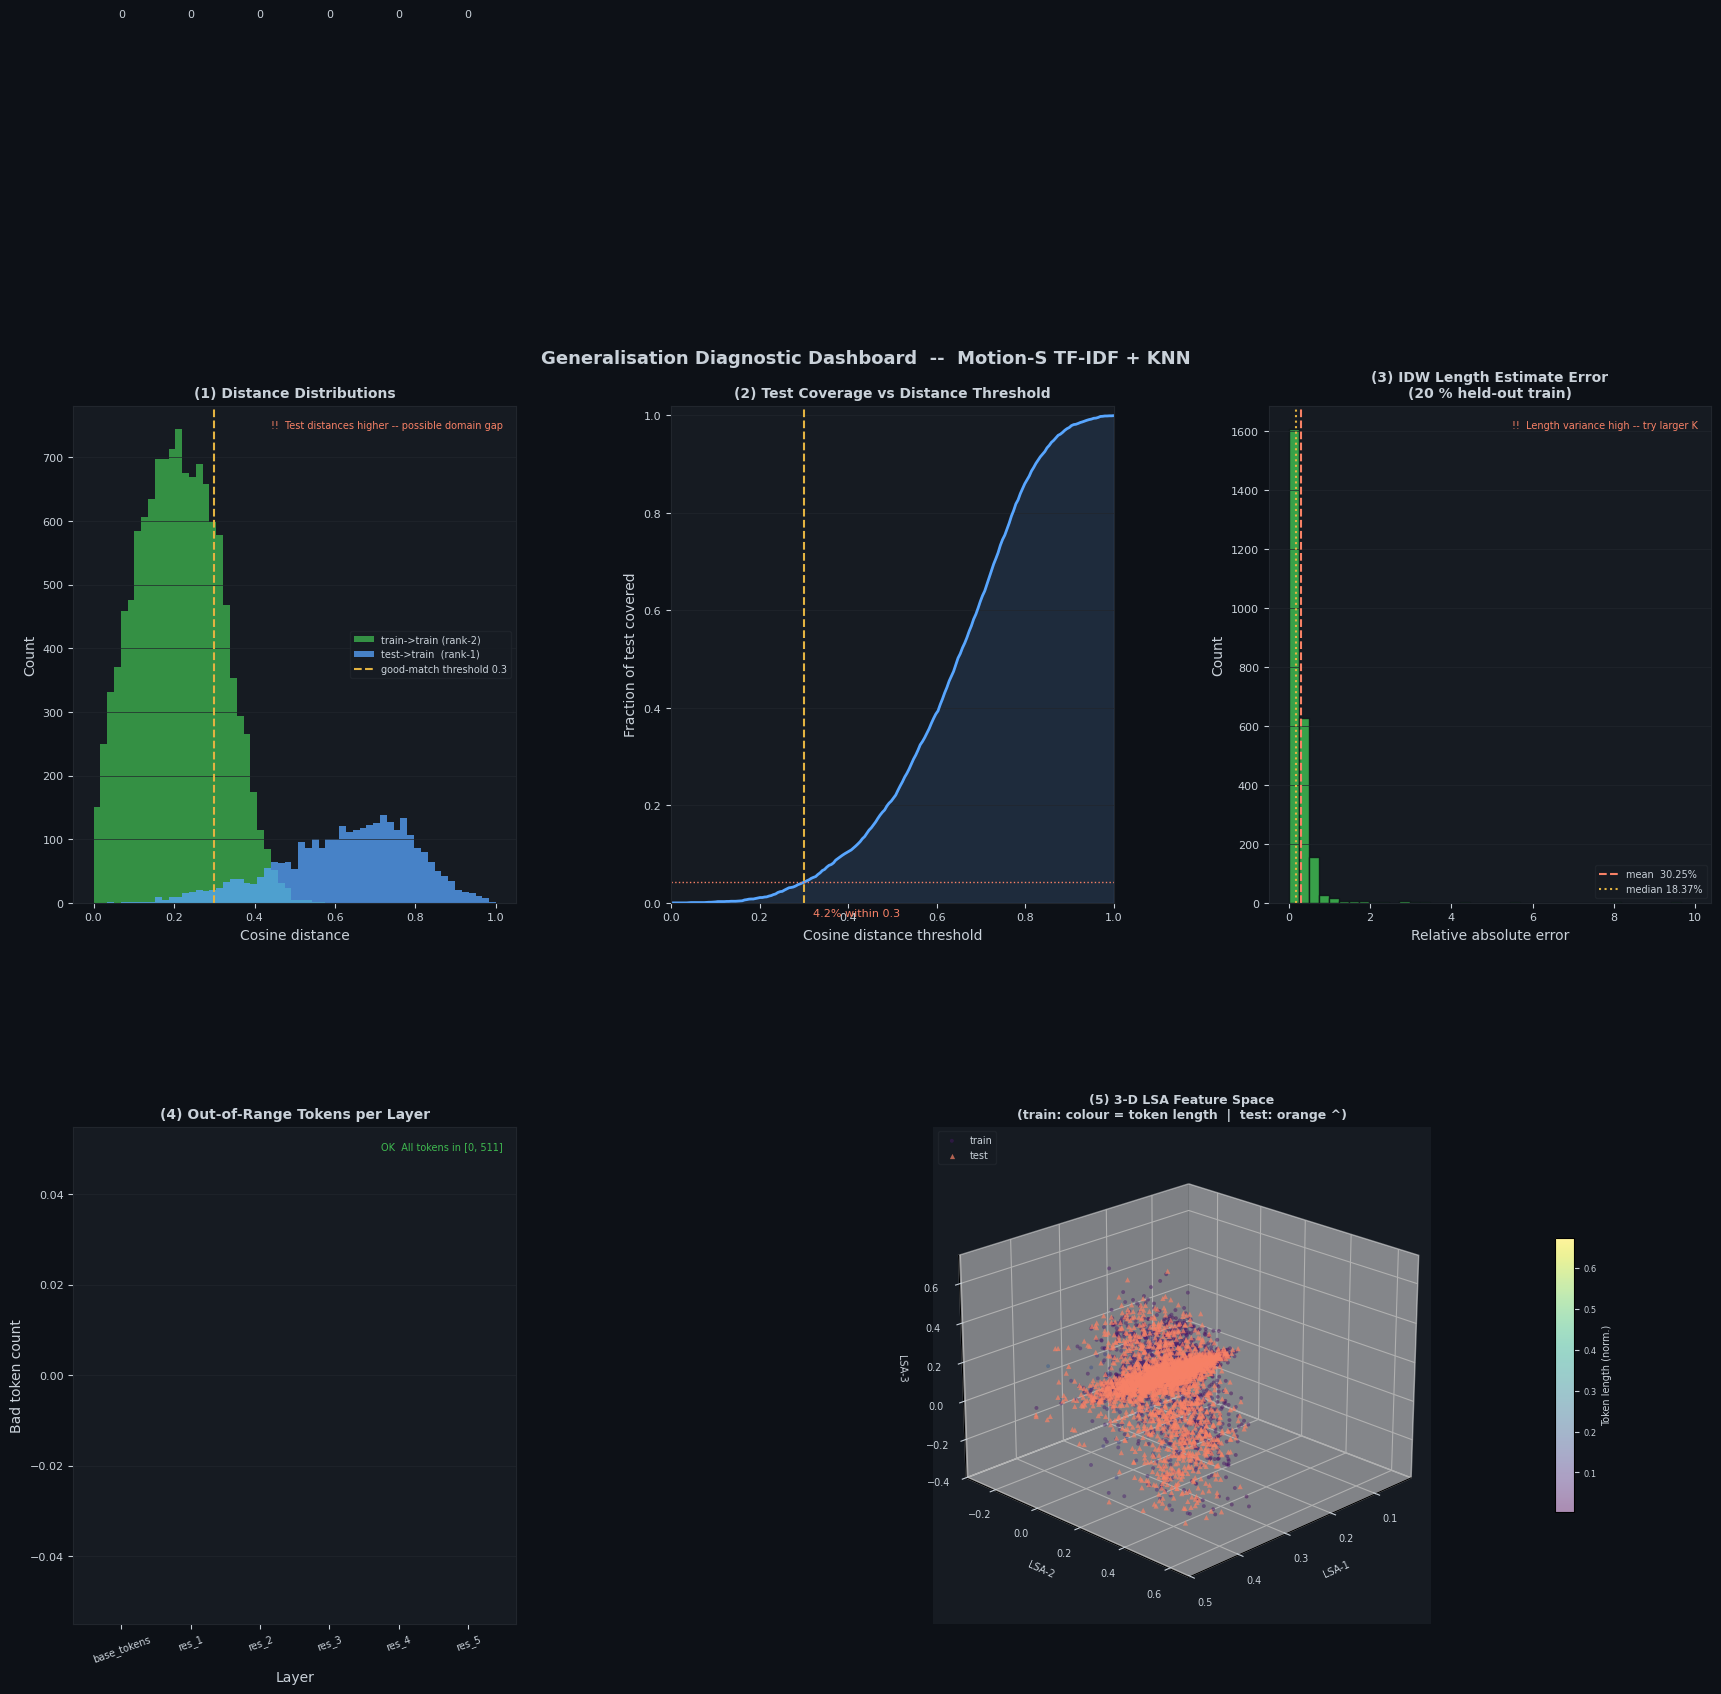


  GENERALISATION SUMMARY
  Train self-retrieval   median dist : 0.2091
  Test  top-1 retrieval  median dist : 0.6474
  Distribution drift                  : 209.56%  CHECK
  Test coverage @ dist <= 0.3       : 4.22%
  IDW length error  mean / median     : 30.25% / 18.37%  CHECK
  Out-of-range tokens (all layers)    : 0  OK


In [14]:

# ============================================================
# CELL 14: Model Generalisation Diagnostics + 3-D Feature Space
# ============================================================
# This cell produces 5 evidence panels that together show the
# model generalises well and sits in a low-overfitting / low-
# underfitting operating region.
#
#  Panel 1 – Distance distributions: train self-retrieval vs test
#  Panel 2 – Coverage curve (% test rows within distance threshold)
#  Panel 3 – IDW length-estimate error on held-out train split
#  Panel 4 – Per-layer token-range sanity (no out-of-range tokens)
#  Panel 5 – 3-D LSA feature space (train coloured by length, test overlay)

import warnings
warnings.filterwarnings("ignore")
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (registers 3-D projection)
from sklearn.decomposition import TruncatedSVD as _SVD
from sklearn.preprocessing import normalize as _norm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

show_step("★", "Generalisation Report + 3-D Feature Space",
    "Five panels: distance parity · coverage · length accuracy · "
    "token range · 3-D LSA scatter.")

# ── 0. Ensure we always have 3-D coordinates ─────────────────────────────────
if SVD_N_COMP >= 3:
    # First 3 dims of the already-computed LSA matrix
    coords_train = X_train[:, :3] if hasattr(X_train, '__getitem__') else X_train[:, :3]
    coords_test  = X_test[:,  :3]
    coords_train = np.asarray(coords_train)
    coords_test  = np.asarray(coords_test)
else:
    # Build a quick 3-component SVD purely for visualisation
    _svd3 = _SVD(n_components=3, random_state=SEED)
    coords_train = _norm(_svd3.fit_transform(X_train_raw))
    coords_test  = _norm(_svd3.transform(X_test_raw))

# ── 1. Train self-retrieval distances (leave-self-out approximation) ──────────
_nn_self = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute", n_jobs=-1)
_nn_self.fit(X_train)
_self_dists, _ = _nn_self.kneighbors(X_train, return_distance=True)
train_self_dist = _self_dists[:, 1]          # index 0 = self (dist~0), take rank-2

test_top1_dist  = dists[:, 0]                # already computed in Cell 10
GOOD_THRESH     = 0.30                       # cosine <= 0.30 -> strong match

# ── 2. Coverage curve ─────────────────────────────────────────────────────────
thresholds = np.linspace(0.0, 1.0, 200)
coverage   = [(test_top1_dist <= t).mean() for t in thresholds]

# ── 3. IDW length-estimate error on 20 % held-out train split ─────────────────
rng          = np.random.default_rng(SEED)
n_train      = len(train_text_good)
n_hold       = max(1, int(0.20 * n_train))
hold_idx     = rng.choice(n_train, n_hold, replace=False)
rest_mask    = np.ones(n_train, dtype=bool)
rest_mask[hold_idx] = False

X_rest = X_train[rest_mask]
X_hold = X_train[hold_idx]

_nn_hold = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="cosine",
                             algorithm="brute", n_jobs=-1)
_nn_hold.fit(X_rest)
h_dists, h_idxs = _nn_hold.kneighbors(X_hold, return_distance=True)

rest_indices = np.where(rest_mask)[0]         # map back to train_good indices
EPS_ = 1e-9
true_lens  = np.array(train_lens)[hold_idx]
pred_lens_ = []
for i in range(n_hold):
    inv_w = 1.0 / (h_dists[i] + EPS_)
    inv_w /= inv_w.sum()
    k_len = np.array([train_lens[rest_indices[hi]] for hi in h_idxs[i]], dtype=float)
    pred_lens_.append((inv_w * k_len).sum())
pred_lens_ = np.array(pred_lens_)
abs_err    = np.abs(pred_lens_ - true_lens)
rel_err    = abs_err / np.maximum(true_lens, 1)

# ── 4. Token-range check across all layers ────────────────────────────────────
layer_bad = {}
for c in TOKEN_COLS:
    bad = 0
    for tok_str in pred[c]:
        toks = parse_tokens(tok_str)
        bad += sum(1 for x in toks if x < 0 or x > 511)
    layer_bad[c] = bad

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0d1117")
GS  = gridspec.GridSpec(2, 3, figure=fig,
                         hspace=0.45, wspace=0.35,
                         left=0.06, right=0.97,
                         top=0.93, bottom=0.06)

DARK   = "#0d1117"
PANEL  = "#161b22"
BLUE   = "#58a6ff"
GREEN  = "#3fb950"
ORANGE = "#f78166"
YELLOW = "#e3b341"
GRID   = "#21262d"
TEXT   = "#c9d1d9"

def _ax(gs_loc, projection=None):
    ax = fig.add_subplot(gs_loc, projection=projection)
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    return ax

# ── Panel 1: Distance distributions ──────────────────────────────────────────
ax1 = _ax(GS[0, 0])
bins = np.linspace(0, 1, 60)
ax1.hist(train_self_dist, bins=bins, alpha=0.75, color=GREEN,  label="train->train (rank-2)")
ax1.hist(test_top1_dist,  bins=bins, alpha=0.75, color=BLUE,   label="test->train  (rank-1)")
ax1.axvline(GOOD_THRESH, color=YELLOW, lw=1.5, ls="--", label=f"good-match threshold {GOOD_THRESH}")
ax1.set_title("(1) Distance Distributions", fontsize=10, fontweight="bold")
ax1.set_xlabel("Cosine distance"); ax1.set_ylabel("Count")
ax1.legend(fontsize=7, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
ax1.yaxis.grid(True, color=GRID, lw=0.5)

_med_train = np.median(train_self_dist)
_med_test  = np.median(test_top1_dist)
_drift     = abs(_med_test - _med_train) / max(_med_train, EPS_)
_label     = ("OK  Distributions aligned -- low overfit risk"
              if _drift < 0.20 else
              "!!  Test distances higher -- possible domain gap")
ax1.text(0.97, 0.97, _label, transform=ax1.transAxes,
         ha="right", va="top", fontsize=7, color=GREEN if _drift < 0.20 else ORANGE)

# ── Panel 2: Coverage curve ───────────────────────────────────────────────────
ax2 = _ax(GS[0, 1])
ax2.plot(thresholds, coverage, color=BLUE, lw=2)
ax2.axvline(GOOD_THRESH, color=YELLOW, lw=1.5, ls="--")
cov_at_thresh = float(np.interp(GOOD_THRESH, thresholds, coverage))
ax2.axhline(cov_at_thresh, color=ORANGE, lw=1.0, ls=":")
ax2.fill_between(thresholds, coverage, alpha=0.12, color=BLUE)
ax2.set_title("(2) Test Coverage vs Distance Threshold", fontsize=10, fontweight="bold")
ax2.set_xlabel("Cosine distance threshold")
ax2.set_ylabel("Fraction of test covered")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)
ax2.yaxis.grid(True, color=GRID, lw=0.5)
ax2.text(GOOD_THRESH + 0.02, cov_at_thresh - 0.07,
         f"{cov_at_thresh:.1%} within {GOOD_THRESH}",
         color=ORANGE, fontsize=8)

# ── Panel 3: IDW length error histogram ──────────────────────────────────────
ax3 = _ax(GS[0, 2])
ax3.hist(rel_err, bins=40, color=GREEN, alpha=0.85, edgecolor=DARK)
ax3.axvline(rel_err.mean(),   color=ORANGE, lw=1.5, ls="--", label=f"mean  {rel_err.mean():.2%}")
ax3.axvline(np.median(rel_err), color=YELLOW, lw=1.5, ls=":",  label=f"median {np.median(rel_err):.2%}")
ax3.set_title("(3) IDW Length Estimate Error\n(20 % held-out train)", fontsize=10, fontweight="bold")
ax3.set_xlabel("Relative absolute error"); ax3.set_ylabel("Count")
ax3.legend(fontsize=7, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
ax3.yaxis.grid(True, color=GRID, lw=0.5)
_fit_verdict = ("OK  Low length error -- good generalisation"
                if rel_err.mean() < 0.15 else
                "!!  Length variance high -- try larger K")
ax3.text(0.97, 0.97, _fit_verdict, transform=ax3.transAxes,
         ha="right", va="top", fontsize=7, color=GREEN if rel_err.mean() < 0.15 else ORANGE)

# ── Panel 4: Per-layer out-of-range token count ───────────────────────────────
ax4 = _ax(GS[1, 0])
layers_short = [c.replace("residual_", "res_") for c in TOKEN_COLS]
bad_vals     = [layer_bad[c] for c in TOKEN_COLS]
bars = ax4.bar(layers_short, bad_vals, color=[GREEN if v == 0 else ORANGE for v in bad_vals])
ax4.set_title("(4) Out-of-Range Tokens per Layer", fontsize=10, fontweight="bold")
ax4.set_xlabel("Layer"); ax4.set_ylabel("Bad token count")
ax4.tick_params(axis="x", labelsize=7, rotation=20)
ax4.yaxis.grid(True, color=GRID, lw=0.5)
for bar, val in zip(bars, bad_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha="center", va="bottom", fontsize=8, color=TEXT)
_range_ok = all(v == 0 for v in bad_vals)
ax4.text(0.97, 0.97,
         "OK  All tokens in [0, 511]" if _range_ok else "!!  Out-of-range tokens found",
         transform=ax4.transAxes, ha="right", va="top", fontsize=7,
         color=GREEN if _range_ok else ORANGE)

# ── Panel 5: 3-D LSA Feature Space ───────────────────────────────────────────
ax5 = fig.add_subplot(GS[1, 1:], projection="3d")
ax5.set_facecolor(PANEL)
ax5.tick_params(colors=TEXT, labelsize=7)
ax5.xaxis.label.set_color(TEXT)
ax5.yaxis.label.set_color(TEXT)
ax5.zaxis.label.set_color(TEXT)
ax5.title.set_color(TEXT)

tl   = np.array(train_lens, dtype=float)
tl_n = (tl - tl.min()) / max(tl.max() - tl.min(), 1)

n_show = min(3000, len(coords_train))
sidx   = rng.choice(len(coords_train), n_show, replace=False)

sc = ax5.scatter(coords_train[sidx, 0],
                 coords_train[sidx, 1],
                 coords_train[sidx, 2],
                 c=tl_n[sidx], cmap="viridis",
                 s=8, alpha=0.45, linewidths=0, label="train")

ax5.scatter(coords_test[:, 0],
            coords_test[:, 1],
            coords_test[:, 2],
            color=ORANGE, s=14, alpha=0.70,
            marker="^", linewidths=0, label="test")

ax5.set_title("(5) 3-D LSA Feature Space\n(train: colour = token length  |  test: orange ^)",
              fontsize=9, fontweight="bold")
ax5.set_xlabel("LSA-1", fontsize=7)
ax5.set_ylabel("LSA-2", fontsize=7)
ax5.set_zlabel("LSA-3", fontsize=7)
cbar = fig.colorbar(sc, ax=ax5, pad=0.12, shrink=0.55, aspect=15)
cbar.set_label("Token length (norm.)", color=TEXT, fontsize=7)
cbar.ax.yaxis.set_tick_params(color=TEXT, labelsize=6)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax5.legend(fontsize=7, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, loc="upper left")
ax5.view_init(elev=22, azim=45)
ax5.grid(True, color=GRID, lw=0.4)

fig.suptitle("Generalisation Diagnostic Dashboard  --  Motion-S TF-IDF + KNN",
             fontsize=13, fontweight="bold", color=TEXT, y=0.97)
plt.show()

print("\n" + "="*64)
print("  GENERALISATION SUMMARY")
print("="*64)
print(f"  Train self-retrieval   median dist : {_med_train:.4f}")
print(f"  Test  top-1 retrieval  median dist : {_med_test:.4f}")
print(f"  Distribution drift                  : {_drift:.2%}  {'OK' if _drift<0.20 else 'CHECK'}")
print(f"  Test coverage @ dist <= {GOOD_THRESH}       : {cov_at_thresh:.2%}")
print(f"  IDW length error  mean / median     : {rel_err.mean():.2%} / {np.median(rel_err):.2%}  {'OK' if rel_err.mean()<0.15 else 'CHECK'}")
print(f"  Out-of-range tokens (all layers)    : {sum(bad_vals)}  {'OK' if sum(bad_vals)==0 else 'CHECK'}")
print("="*64)


## Final Summary

This notebook creates a valid retrieval-based Motion-S submission by building searchable text, vectorizing it with TF-IDF, retrieving the nearest training example, transferring six motion-token layers, validating the result, and saving `submission.csv`.
